In [64]:
import cv2 
import matplotlib.pyplot as plt


img_1 = cv2.imread("../KITTI/training/image_0/000045_10.png")
img_2 = cv2.imread("../KITTI/training/image_0/000045_11.png")

In [73]:
def visualize_flow(u, v):
    hsv = np.zeros((u.shape[0], u.shape[1], 3), dtype=np.uint8)
    hsv[..., 1] = 255
    mag, ang = cv2.cartToPolar(u, v)
    hsv[..., 0] = ang * 180 / np.pi / 2
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
    bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    return bgr

Valid pixels: 104330


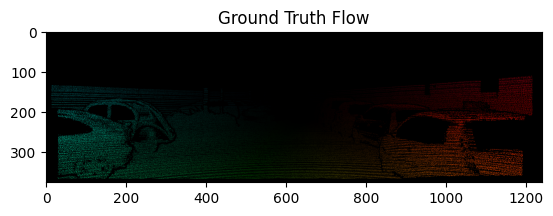

In [76]:
import numpy as np
optical_flow = cv2.imread("../KITTI/training/flow_noc/000045_10.png",cv2.IMREAD_UNCHANGED)

gt_flow_u = (optical_flow[:, :, 2].astype(float) - 2**15) / 64.0
gt_flow_v = (optical_flow[:, :, 1].astype(float) - 2**15) / 64.0
gt_valid  = optical_flow[:, :, 0] > 0

gt_flow_u[~gt_valid] = 0
gt_flow_v[~gt_valid] = 0

print(f"Valid pixels: {np.sum(gt_valid)}")

plt.imshow(cv2.cvtColor(visualize_flow(gt_flow_u,gt_flow_v), cv2.COLOR_BGR2RGB))
plt.title("Ground Truth Flow")
plt.show()


## PyFlow

In [77]:
from PIL import Image
import pyflow
import time

img_1 = np.array(Image.open("../KITTI/training/image_0/000045_10.png")) 
img_2 = np.array(Image.open("../KITTI/training/image_0/000045_11.png")) 

img_1 = np.expand_dims(img_1.astype(float) / 255.0,axis=2)
img_2 = np.expand_dims(img_2.astype(float) / 255.0,axis=2)

print(img_1.shape)

alpha = 0.012
ratio = 0.75
minWidth = 20
nOuterFPIterations = 7
nInnerFPIterations = 1
nSORIterations = 30
colType = 1  # 0 or default:RGB, 1:GRAY (but pass gray image with shape (h,w,1))

s = time.time()
u, v, im2W = pyflow.coarse2fine_flow(
    img_1, img_2, alpha, ratio, minWidth, nOuterFPIterations, nInnerFPIterations,
    nSORIterations, colType)
e = time.time()
print('Time Taken: %.2f seconds for image of size (%d, %d, %d)' % (
    e - s, img_1.shape[0], img_1.shape[1], img_1.shape[2]))
flow = np.concatenate((u[..., None], v[..., None]), axis=2)

(376, 1241, 1)
Constructing pyramid...Time Taken: 5.00 seconds for image of size (376, 1241, 1)
done!
Pyramid level 13
Pyramid level 12
Pyramid level 11
Pyramid level 10
Pyramid level 9
Pyramid level 8
Pyramid level 7
Pyramid level 6
Pyramid level 5
Pyramid level 4
Pyramid level 3
Pyramid level 2
Pyramid level 1
Pyramid level 0


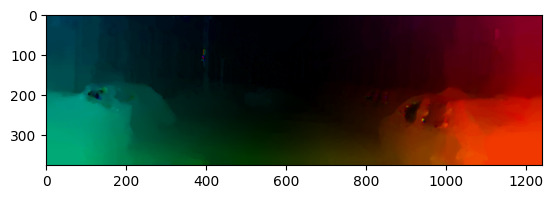

In [78]:
flow_img = visualize_flow(u, v)
plt.imshow(cv2.cvtColor(flow_img, cv2.COLOR_BGR2RGB))
plt.show()

## Metrics

In [79]:
gt_flow_u[~gt_valid] = 0
gt_flow_v[~gt_valid] = 0

u[~gt_valid] = 0
v[~gt_valid] = 0

gt = np.zeros((u.shape[0], u.shape[1],2))
gt[:,:,0] = gt_flow_u
gt[:,:,1] = gt_flow_v

pred = np.zeros((u.shape[0], u.shape[1],2))
pred[:,:,0] = u
pred[:,:,1] = v


mse = np.sum(np.square(gt - pred)) / np.sum(gt_valid)

print(mse)

3.703792670580564


## FlowFormerPlusPlus

In [80]:
import sys
import os
import torch
import torch.nn as nn

import os

os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"

os.environ["CUDA_VISIBLE_DEVICES"]="0"


if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())


from core.FlowFormer import build_flowformer 
from core.utils.misc import process_cfg
from configs.kitti import get_cfg 


def load_model(checkpoint_path):
    cfg = get_cfg()
    
    model = nn.DataParallel(build_flowformer(cfg))
    
    print(f"Loading checkpoint: {checkpoint_path}")
    state_dict = torch.load(checkpoint_path, map_location='cpu')
    
    # FlowFormer often saves the state_dict directly or under 'model'
    if 'model' in state_dict:
        model.load_state_dict(state_dict['model'])
    else:
        model.load_state_dict(state_dict)
        
    model.eval()
    if torch.cuda.is_available():
        model.cuda()
    return model

# Example Usage (uncomment once paths are set):
CHECKPOINT = 'checkpoints/kitti.pth'
model = load_model(CHECKPOINT)

/home/msiau/data/tmp/jventosa/miniconda3/envs/master_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/msiau/data/tmp/jventosa/miniconda3/envs/master_env/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/home/msiau/data/tmp/jventosa/miniconda3/envs/master_env/lib/python3.11/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/home/msiau/data/tmp/jventosa/miniconda3/envs/master_env/lib/python3.11/s

ImportError: cannot import name 'overlay_external_default_cfg' from 'timm.models.helpers' (/home/msiau/data/tmp/jventosa/miniconda3/envs/master_env/lib/python3.11/site-packages/timm/models/helpers.py)

In [ ]:
from PIL import Image
import torch
import numpy as np

def load_grayscale_as_rgb(imfile):
    # Load as grayscale ('L')
    img_gray = Image.open(imfile).convert('L')
    img_np = np.array(img_gray)
    
    # Convert to RGB by stacking the single channel 3 times
    img_rgb = np.stack([img_np, img_np, img_np], axis=-1)
    
    # Convert to Tensor: [H, W, 3] -> [3, H, W] -> [1, 3, H, W]
    img_tensor = torch.from_numpy(img_rgb).permute(2, 0, 1).float()
    return img_tensor[None].cuda()

def get_uv_from_gray(model, path1, path2):
    image1 = load_grayscale_as_rgb(path1)
    image2 = load_grayscale_as_rgb(path2)
    
    
    print(image1.shape)
    # Padding is required for the Transformer architecture (usually multiple of 8)
    from core.utils.utils import InputPadder
    from core.utils.utils import InputPadder

    # 1. Prepare images
    padder = InputPadder(image1.shape)
    image1_padded, image2_padded = padder.pad(image1, image2)

    # 2. Inference
    with torch.no_grad():
        output = {}
        flow_predictions = model(image1_padded, image2_padded, output)
        target_h, target_w = gt_flow_u.shape

        flow_final = resize_flow_to_gt(flow_predictions[-1], target_h, target_w)
        flow_final = flow_final.cpu().squeeze(0)

        u = flow_final[0].numpy()
        v = flow_final[1].numpy()


    return u, v

u, v = get_uv_from_gray(model, "../../KITTI/training/image_0/000045_10.png", "../../KITTI/training/image_0/000045_11.png")

In [ ]:
gt_flow_u[~gt_valid] = 0
gt_flow_v[~gt_valid] = 0

print(u.shape)

u[~gt_valid] = 0
v[~gt_valid] = 0

gt = np.zeros((u.shape[0], u.shape[1],2))
gt[:,:,0] = gt_flow_u
gt[:,:,1] = gt_flow_v

pred = np.zeros((u.shape[0], u.shape[1],2))
pred[:,:,0] = u
pred[:,:,1] = v


mse = np.sum(np.square(gt - pred)) / np.sum(gt_valid)

print(mse)

In [ ]:
flow_img = visualize_flow(u, v)
plt.imshow(cv2.cvtColor(flow_img, cv2.COLOR_BGR2RGB))
plt.show()

## NeuFlow v2

In [ ]:
import torch
from glob import glob
import os
import numpy as np
import cv2
from NeuFlow.neuflow import NeuFlow
from NeuFlow.backbone_v7 import ConvBlock
from data_utils import flow_viz
from PIL import Image

image_width = 768
image_height = 432

def get_cuda_image(image_path):
    img_gray = Image.open(image_path).convert('L')
    img_np = np.array(img_gray)
    
    # Convert to RGB by stacking the single channel 3 times
    img_rgb = np.stack([img_np, img_np, img_np], axis=-1)
    img_rgb = cv2.resize(img_rgb, (image_width, image_height))
    image = torch.from_numpy(img_rgb).permute(2, 0, 1).half()
    return image[None].cuda()


def fuse_conv_and_bn(conv, bn):
        """Fuse Conv2d() and BatchNorm2d() layers https://tehnokv.com/posts/fusing-batchnorm-and-conv/."""
        fusedconv = (
            torch.nn.Conv2d(
                conv.in_channels,
                conv.out_channels,
                kernel_size=conv.kernel_size,
                stride=conv.stride,
                padding=conv.padding,
                dilation=conv.dilation,
                groups=conv.groups,
                bias=True,
            )
            .requires_grad_(False)
            .to(conv.weight.device)
        )

        # Prepare filters
        w_conv = conv.weight.clone().view(conv.out_channels, -1)
        w_bn = torch.diag(bn.weight.div(torch.sqrt(bn.eps + bn.running_var)))
        fusedconv.weight.copy_(torch.mm(w_bn, w_conv).view(fusedconv.weight.shape))

        # Prepare spatial bias
        b_conv = torch.zeros(conv.weight.shape[0], device=conv.weight.device) if conv.bias is None else conv.bias
        b_bn = bn.bias - bn.weight.mul(bn.running_mean).div(torch.sqrt(bn.running_var + bn.eps))
        fusedconv.bias.copy_(torch.mm(w_bn, b_conv.reshape(-1, 1)).reshape(-1) + b_bn)

        return fusedconv



device = torch.device('cuda')

model = NeuFlow.from_pretrained("Study-is-happy/neuflow-v2").to(device)

for m in model.modules():
    if type(m) is ConvBlock:
        m.conv1 = fuse_conv_and_bn(m.conv1, m.norm1)  # update conv
        m.conv2 = fuse_conv_and_bn(m.conv2, m.norm2)  # update conv
        delattr(m, "norm1")  # remove batchnorm
        delattr(m, "norm2")  # remove batchnorm
        m.forward = m.forward_fuse  # update forward

model.eval()
model.half()

model.init_bhwd(1, image_height, image_width, 'cuda')



image_0 = get_cuda_image("../KITTI/training/image_0/000045_10.png")
image_1 = get_cuda_image("../KITTI/training/image_0/000045_11.png")

print()

with torch.no_grad():

    flow = model(image_0, image_1)[-1][0]

    flow = flow.permute(1,2,0).cpu().numpy()
    




/home/msiau/data/tmp/jventosa/miniconda3/envs/flowformerpp/lib/python3.8/site-packages/torch/nn/modules/module.py:811: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten/src/ATen/core/TensorBody.h:489.)
  param_grad = param.grad


In [41]:
flow = np.ascontiguousarray(flow.astype(np.float32))

In [44]:

target_shape = (gt_flow_u.shape[1], gt_flow_u.shape[0]) 

flow_resized =  cv2.resize(flow, target_shape, interpolation=cv2.INTER_LINEAR)

scale_x = target_shape[0] / flow.shape[1]
scale_y = target_shape[1] / flow.shape[0]

flow_resized[:,:,0] *= scale_x
flow_resized[:,:,1] *= scale_y

print(f"Resized U/V shape: {u.shape}, matching GT.")

Resized U/V shape: (376, 1241), matching GT.


In [46]:
gt_flow_u[~gt_valid] = 0
gt_flow_v[~gt_valid] = 0
print(gt_flow_u.max())
print(u.shape)

flow_resized[:,:,0][~gt_valid] = 0
flow_resized[:,:,1][~gt_valid] = 0

gt = np.zeros((u.shape[0], u.shape[1],2))
gt[:,:,0] = gt_flow_u
gt[:,:,1] = gt_flow_v

pred = np.zeros((u.shape[0], u.shape[1],2))
pred[:,:,0] = flow_resized[:,:,0]
pred[:,:,1] = flow_resized[:,:,1]


mse = np.sum(np.square(gt - pred)) / np.sum(gt_valid)

print(mse)

49.375
(376, 1241)
2.5666041599954


In [ ]:
flow_img = visualize_flow(flow_resized[:,:,0], flow_resized[:,:,1])
plt.imshow(cv2.cvtColor(flow_img, cv2.COLOR_BGR2RGB))
plt.show()